# Training Analysis Notebook

This notebook analyzes the trained models on a classification task ordinary vs accidental.

## Contents

- Loading and parsing training statistics
- Training curves
- Model evaluation on test set
- Sample results

In [2]:
# Import libraries
import sys
sys.path.append('..')

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, accuracy_score
from torch.utils.data import DataLoader
from PIL import Image
from torchvision import transforms
from src.model import build_model
from src.data_pipeline import ImagePathDataset

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [41]:
# Function to parse stats txt file
def parse_stats_file(filepath):
    epochs = []
    train_loss = []
    train_acc = []
    train_f1 = []
    val_loss = []
    val_acc = []
    val_f1 = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Match epoch summary lines
            epoch_match = re.search(r'Epoch (\d+)/\d+ - [\d.]+s', line)
            if epoch_match:
                epoch = int(epoch_match.group(1))
                epochs.append(epoch)
            
            train_match = re.search(r'train loss: ([\d.]+) acc: ([\d.]+) f1: ([\d.]+)', line)
            if train_match:
                train_loss.append(float(train_match.group(1)))
                train_acc.append(float(train_match.group(2)))
                train_f1.append(float(train_match.group(3)))
            
            val_match = re.search(r'val   loss: ([\d.]+) acc: ([\d.]+) f1: ([\d.]+)', line)
            if val_match:
                val_loss.append(float(val_match.group(1)))
                val_acc.append(float(val_match.group(2)))
                val_f1.append(float(val_match.group(3)))
    
    return {
        'epochs': epochs,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'train_f1': train_f1,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1
    }

# Load stats for both experiments
outputs_dir = '../outputs/models'
experiments = {}
for filename in os.listdir(outputs_dir):
    if filename.endswith('_stats.txt'):
        exp_name = filename.replace('_stats.txt', '')
        filepath = os.path.join(outputs_dir, filename)
        experiments[exp_name] = parse_stats_file(filepath)

print("Loaded experiments:", list(experiments.keys()))

Loaded experiments: ['resnet_class_weight', 'resnet_downsample', 'resnet_none', 'resnet_oversample']


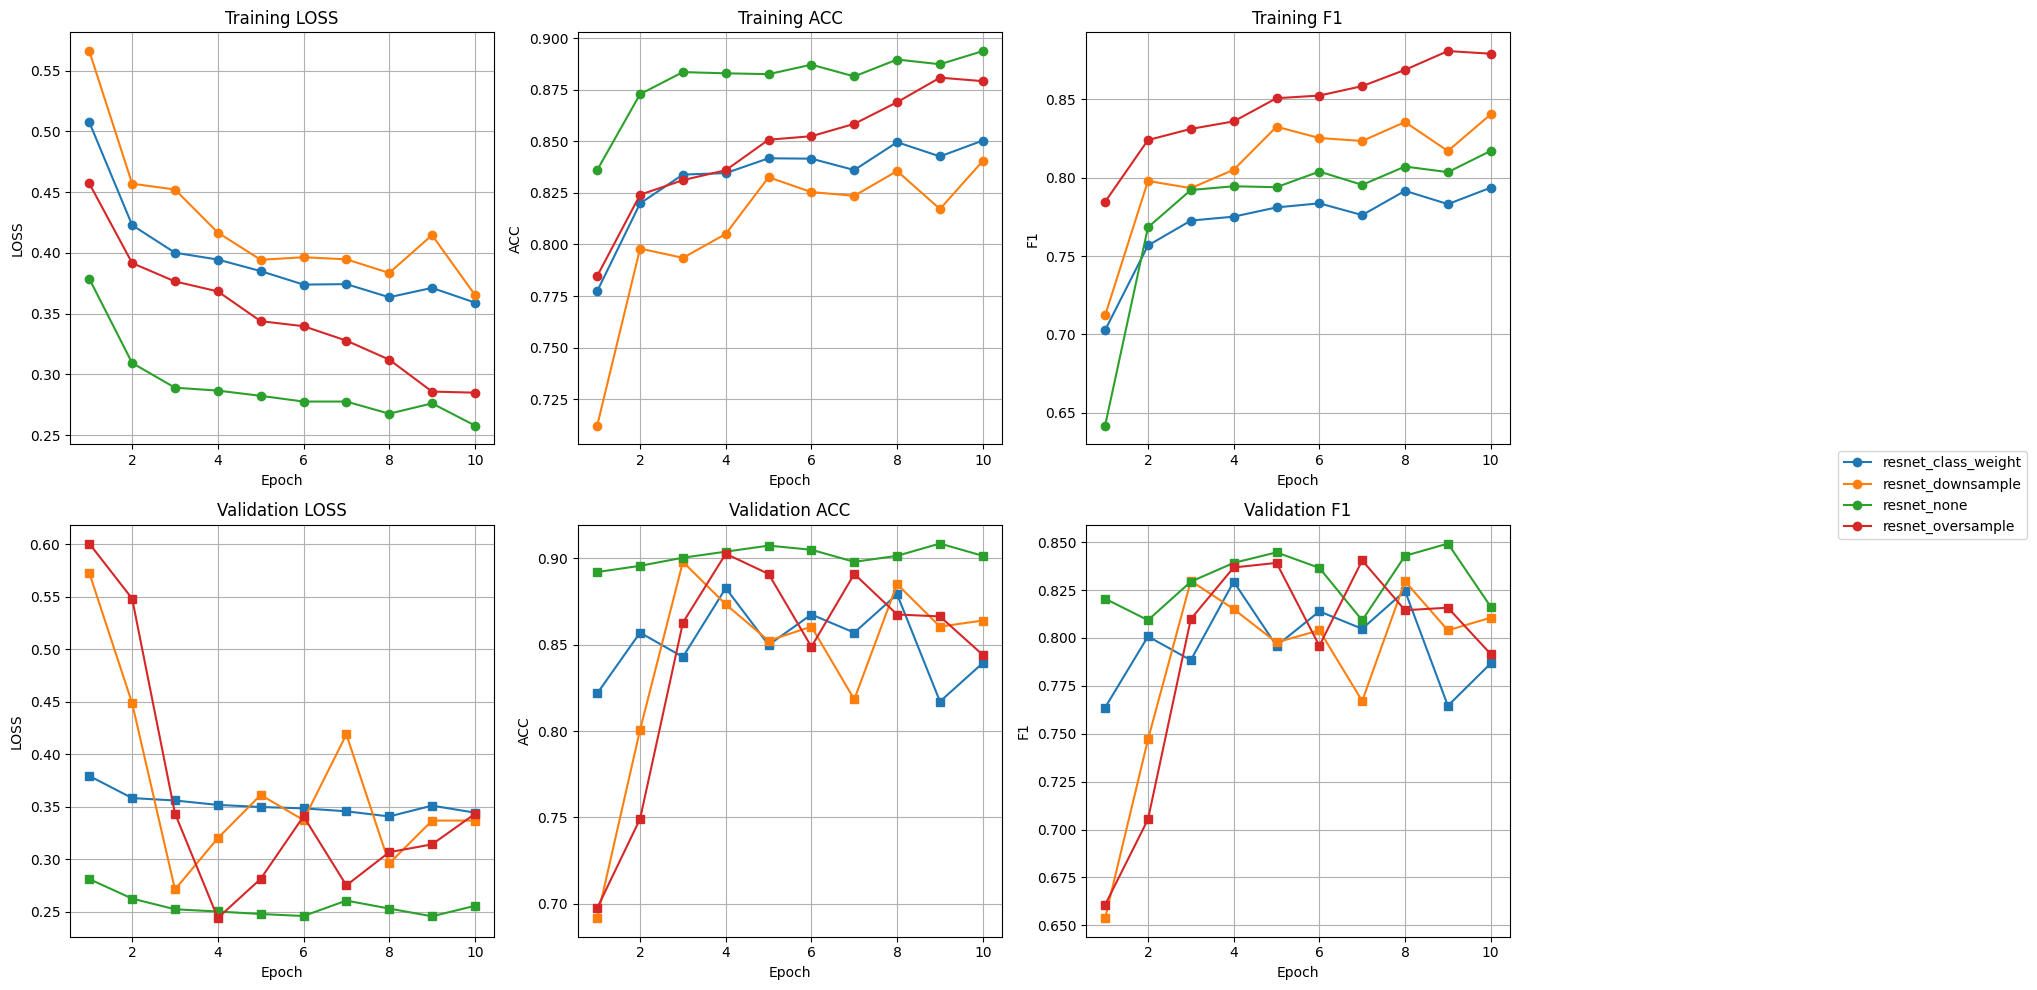

In [42]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['loss', 'acc', 'f1']

# Store handles/labels once for global legend
handles = []
labels = []

for i, metric in enumerate(metrics):
    ax_train = axes[0, i]
    ax_val = axes[1, i]
    
    for exp_name, data in experiments.items():
        epochs = data['epochs']
        train_vals = data[f'train_{metric}']
        val_vals = data[f'val_{metric}']
        
        train_line, = ax_train.plot(
            epochs, train_vals, label=exp_name, marker='o'
        )
        ax_val.plot(
            epochs, val_vals, label=exp_name, marker='s'
        )
        
        if i == 0:
            handles.append(train_line)
            labels.append(exp_name)
    
    ax_train.set_title(f'Training {metric.upper()}')
    ax_train.set_xlabel('Epoch')
    ax_train.set_ylabel(metric.upper())
    ax_train.grid(True)
    
    ax_val.set_title(f'Validation {metric.upper()}')
    ax_val.set_xlabel('Epoch')
    ax_val.set_ylabel(metric.upper())
    ax_val.grid(True)

fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10
)

# Leave space on right for legend
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

In [34]:
# Load test data
test_csv = '../outputs/splits/test_records.csv'
test_df = pd.read_csv(test_csv)

unique_labels = sorted(test_df["label"].unique())
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {v: k for k, v in label_to_index.items()}   # Good to verify

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

test_records = [{'path': '../' + row['path'], 'label': row['label']} for _, row in test_df.iterrows()]
test_dataset = ImagePathDataset(test_records, label_to_index, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
print("Label mapping used:", label_to_index, len(test_dataset))

Label mapping used: {'accidental': 0, 'ordinary': 1} 853


In [ ]:
# Function to evaluate model on test set
def evaluate_model(model_path, test_loader, device):
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    config = checkpoint['config']

    selected_labels = (
        config.get('experiment', {}).get('selected_labels')
        or config.get('selected_labels')
        or ['ordinary', 'accidental']
    )
    num_classes = len(selected_labels)

    # Build model
    model = build_model(config, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
    
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')
    
    return {'accuracy': acc, 'f1': f1}

# Evaluate both models
test_results = {}
for exp_name in experiments.keys():
    model_path = os.path.join(outputs_dir, f'{exp_name}.pt')
    if os.path.exists(model_path):
        test_results[exp_name] = evaluate_model(model_path, test_loader, device)
    else:
        print(f"Model file not found: {model_path}")


In [36]:
# Compare final validation metrics
final_metrics = {}
for exp_name, data in experiments.items():
    final_epoch = data['epochs'][-1]
    final_metrics[exp_name] = {
        'val_loss': data['val_loss'][-1],
        'val_acc': data['val_acc'][-1],
        'val_f1': data['val_f1'][-1],
        'test_acc': test_results.get(exp_name, {}).get('accuracy', None),
        'test_f1': test_results.get(exp_name, {}).get('f1', None)
    }

comparison_df = pd.DataFrame.from_dict(final_metrics, orient='index')
print("Final Comparison:")
print(comparison_df)

Final Comparison:
                         val_loss  val_acc  val_f1  test_acc   test_f1
bug_resnet_class_weight    0.3444   0.8394  0.7867  0.889801  0.828864
bug_resnet_none            0.2556   0.9015  0.8163  0.888628  0.810358
resnet_downsample          0.3073   0.8792  0.8212  0.879250  0.807836
resnet_oversample          0.3266   0.8558  0.8029  0.881594  0.806217


,index,path,true_label,resnet_class_weight,resnet_downsample,resnet_none,resnet_oversample
0,0,../data\raw\reddit_data\953ce3b2c8ace4d2.jpg,accidental,accidental,accidental,accidental,accidental
1,1,../data\raw\coco_data\3277.jpg,ordinary,accidental,accidental,accidental,accidental
2,2,../data\raw\coco_data\111.jpg,ordinary,ordinary,ordinary,ordinary,ordinary
3,3,../data\raw\coco_data\1634.jpg,ordinary,ordinary,ordinary,ordinary,ordinary
4,4,../data\raw\reddit_data\a9e75d3c294914b5.jpg,accidental,accidental,accidental,accidental,accidental


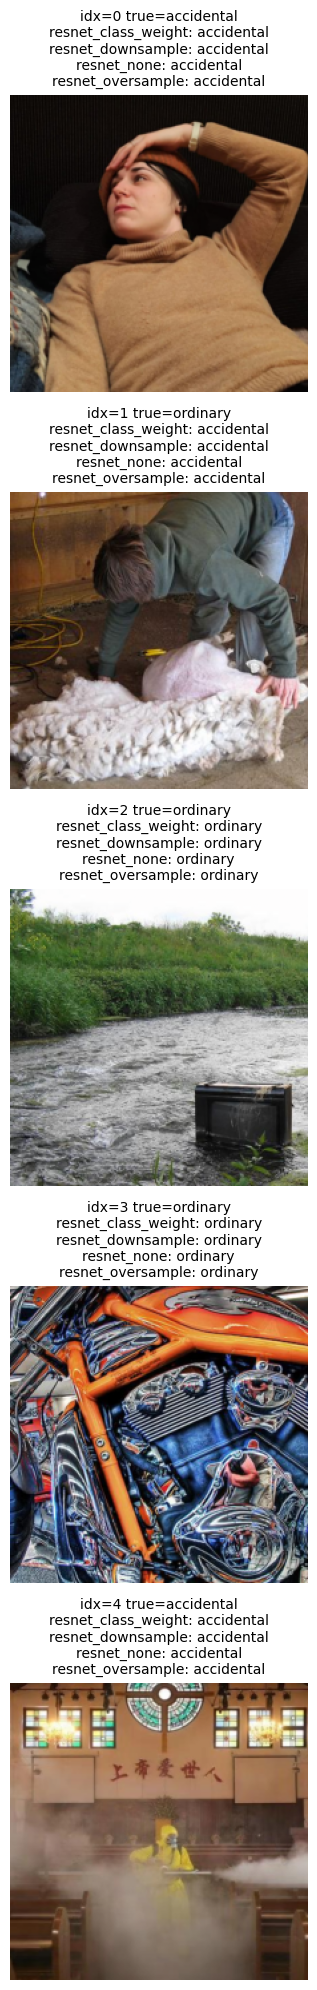

In [43]:
# Sample some test examples and compare model predictions
sample_indices = [0, 1, 2, 3, 4]
sample_records = [test_records[i] for i in sample_indices]

images = []
targets = []
for rec in sample_records:
    img = Image.open(rec['path']).convert('RGB')
    images.append(transform(img))
    targets.append(label_to_index[rec['label']])

images = torch.stack(images).to(device)
targets = torch.tensor(targets)

model_preds = {}
for exp_name in experiments.keys():
    model_path = os.path.join(outputs_dir, f'{exp_name}.pt')
    if not os.path.exists(model_path):
        continue

    checkpoint = torch.load(model_path, map_location=device)
    cfg = checkpoint['config']
    selected_labels = (
        cfg.get('experiment', {}).get('selected_labels')
        or cfg.get('selected_labels')
        or ['ordinary', 'accidental']
    )
    num_classes = len(selected_labels)

    model = build_model(cfg, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().tolist()

    model_preds[exp_name] = preds

rows = []
for i, rec in enumerate(sample_records):
    row = {
        'index': sample_indices[i],
        'path': rec['path'],
        'true_label': rec['label']
    }
    for exp_name, preds in model_preds.items():
        row[exp_name] = index_to_label[preds[i]]
    rows.append(row)

sample_df = pd.DataFrame(rows)
# Sample some test examples and compare model predictions
sample_indices = [0, 1, 2, 3, 4]

batch_images, batch_targets = next(iter(test_loader))
sample_images = batch_images[sample_indices].to(device)

model_preds = {}
for exp_name in experiments:
    model_path = os.path.join(outputs_dir, f'{exp_name}.pt')
    if not os.path.exists(model_path):
        continue

    checkpoint = torch.load(model_path, map_location=device)
    cfg = checkpoint['config']
    selected_labels = (
        cfg.get('experiment', {}).get('selected_labels')
        or cfg.get('selected_labels')
        or ['ordinary', 'accidental']
    )
    num_classes = len(selected_labels)

    model = build_model(cfg, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()

    with torch.no_grad():
        outputs = model(sample_images)
        model_preds[exp_name] = outputs.argmax(dim=1).cpu().tolist()

rows = []
for pos, idx in enumerate(sample_indices):
    row = {
        'index': idx,
        'path': test_records[idx]['path'],
        'true_label': test_records[idx]['label']
    }
    for exp_name, preds in model_preds.items():
        row[exp_name] = index_to_label[preds[pos]]
    rows.append(row)

sample_df = pd.DataFrame(rows)

inv_norm = transforms.Normalize(
    mean=[-m / s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1 / s for s in [0.229, 0.224, 0.225]]
)

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(10, 4 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = [axes]

for pos, idx in enumerate(sample_indices):
    img = inv_norm(sample_images[pos].cpu()).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()

    ax = axes[pos]
    ax.imshow(img)
    ax.axis('off')

    pred_lines = "\n".join(
        f"{exp}: {index_to_label[model_preds[exp][pos]]}"
        for exp in model_preds
    )
    ax.set_title(
        f"idx={idx} true={test_records[idx]['label']}\n{pred_lines}",
        fontsize=10
    )

plt.tight_layout()
sample_df